<a href="https://colab.research.google.com/github/JCSR2022/challenge3-data-science-Alura/blob/main/data/Data_Preprocessing_Stage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Telecom X – Customer Churn Prediction

## Data Preprocessing Stage

### Project Context

Telecom X faces a critical business challenge: **customer churn**. Customer cancellations directly impact revenue stability, increase acquisition costs, and affect long-term growth.

The objective of this project is to develop **Machine Learning models capable of predicting which customers are most likely to cancel their services** before churn occurs.

This stage represents the transition from **exploratory data analysis to predictive modeling**, where the focus shifts to preparing the dataset to ensure reliable, interpretable, and high-performance models.

Some of this work was made on the Challenge 2 , but in this ocasion the focus will be on billding a pipeline that allow take this process to production.

---

# 🧠 Data Preprocessing Pipeline

The preprocessing stage prepares the raw dataset for Machine Learning modeling by cleaning, transforming, and selecting relevant features.


# Environment configuration

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin



import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
from seaborn.palettes import color_palette


import warnings
#warnings.filterwarnings("ignore")

In [2]:
# -----------------------------
# 0. Visual configuration
# -----------------------------
sns.set_theme(style="white", font_scale=1.1)

#color_palette_options = ["viridis","rocket","Blues","crest","flare","magma","rocket_r"]
curr_color = "crest"
CMAP = sns.color_palette(curr_color, as_cmap=True)

# to avoid to dark or to white colors
COLOR_MIN = 0.2
COLOR_MAX = 0.8
def value_to_color(v, vmin, vmax):
    norm = Normalize(vmin, vmax)
    return CMAP(COLOR_MIN + (COLOR_MAX - COLOR_MIN) * norm(v))


#style must be one of white, dark, whitegrid, darkgrid, ticks
sns.set_theme(
    style="whitegrid",
    palette=curr_color,
    font="sans-serif",
    font_scale=1.1
)


#For all random
my_random_seed = 42



def show_table(df, column=None):

    if column:
        df = df.sort_values(by=column, ascending=False)

        vmin = df[column].min()
        vmax = df[column].max()

        def style_cell(v):
            r, g, b, _ = value_to_color(v, vmin, vmax)
            return f'background-color: rgb({int(r*255)}, {int(g*255)}, {int(b*255)})'

        styled = df.style.applymap(style_cell, subset=[column])

    else:
        styled = df.style

    return (
        styled
        .format(precision=2)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th",
             "props": [
                 ("font-weight", "bold"),
                 ("text-align", "center")
             ]}
        ])
    )



def barplot(df, x, y, title, y_unit=None, x_unit=None):

    df = df.sort_values(by=y, ascending=False)

    norm = Normalize(df[y].min(), df[y].max())

    colors = [ CMAP(COLOR_MIN + (COLOR_MAX - COLOR_MIN) * norm(v))for v in df[y] ]

    fig, ax = plt.subplots(figsize=(10,6))

    bars = ax.bar(df[x], df[y], color=colors)

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(x + (f" [{x_unit}]" if x_unit else ""))
    ax.set_ylabel(y + (f" [{y_unit}]" if y_unit else ""))


    offset = df[y].max() * 0.01

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + offset,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

    sns.despine()
    plt.tight_layout()

    return fig


def distribution_plot(df, x, title=None, bins=None, x_unit=None):

    data = df[x].dropna()

    mean_val = data.mean()
    median_val = data.median()

    if bins is None:
        q75, q25 = np.percentile(data, [75, 25])
        iqr = q75 - q25
        n = len(data)

        bin_width = 2 * iqr / n**(1/3)

        if bin_width > 0:
            bins = int((data.max() - data.min()) / bin_width)
        else:
            bins = 20

    hist_color = CMAP(0.55)
    kde_color = CMAP(0.9)
    box_color = CMAP(0.55)
    edge_color = CMAP(0.9)

    mean_color = CMAP(0.95)
    median_color = CMAP(0.75)

    fig, (ax_hist, ax_box) = plt.subplots(
        2,
        1,
        figsize=(6,4),
        gridspec_kw={"height_ratios": [4, 1]},
        sharex=True
    )

    sns.histplot(
        data=data,
        bins=bins,
        kde=True,
        color=hist_color,
        edgecolor="white",
        ax=ax_hist
    )

    if ax_hist.lines:
        ax_hist.lines[0].set_color(kde_color)
        ax_hist.lines[0].set_linewidth(2)

    ax_hist.axvline(mean_val, color=mean_color, linestyle="--", linewidth=2)
    ax_hist.axvline(median_val, color=median_color, linestyle="-", linewidth=2)

    stats_text = (
        f"Mean: {mean_val:.2f}\n"
        f"Median: {median_val:.2f}"
        + (f" {x_unit}" if x_unit else "")
    )

    ax_hist.text(
        0.98,
        0.95,
        stats_text,
        transform=ax_hist.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )

    ax_hist.set_title(
        title if title else f'Distribution of {x}',
        fontsize=14,
        weight="bold"
    )

    ax_hist.set_ylabel("Count")

    # -------- Boxplot --------
    sns.boxplot(
        x=data,
        ax=ax_box,
        color=box_color,
        width=0.4,
        fliersize=3,
        linewidth=1.5
    )

    for line in ax_box.lines:
        line.set_color(edge_color)
        line.set_linewidth(1.5)

    ax_box.set_xlabel(x + (f" [{x_unit}]" if x_unit else ""))
    ax_box.set_ylabel("")

    sns.despine(ax=ax_hist)
    sns.despine(ax=ax_box)

    plt.tight_layout()

    return fig

def corr_plot(df, title="Correlation Matrix"):

    corr = df.select_dtypes(include=[np.number]).corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(
        corr,
        mask=mask,
        cmap=CMAP,
        vmax=1.0,
        vmin=-1.0,
        center=0,
        annot=True,
        fmt=".2f",
        square=True,
        linewidths=.5,
        annot_kws={"size": 8},
        cbar_kws={"shrink": .8},
        ax=ax
    )

    ax.set_title(title, fontsize=16, weight="bold", pad=20)

    ax.tick_params(axis='both', which='major', labelsize=10)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    return fig



def inspect_preprocessor(preprocessor, X):
    Xt = preprocessor.fit_transform(X)
    return pd.DataFrame(
        Xt if not hasattr(Xt, "toarray") else Xt.toarray(),
        columns=preprocessor.get_feature_names_out()
    )

# Data load and cleaning

This step includes:

- Converting categorical variables into numerical format

- Ensuring numerical variables have correct data types (float, int)

- Converting binary categorical variables (Yes/No) into 0/1 encoding

- Verifying date or tenure-related variables are properly formatted

**Proper formatting guarantees compatibility with ML algorithms.**

In [3]:
# ================================
# 1. Load Data
# ================================

url_data = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data_raw = pd.read_json(url_data)
data = pd.json_normalize(data_raw.to_dict(orient="records"))

In [4]:
# ================================
# 2. Data Cleaning
# ================================

# keep valid target labels
data = data[data["Churn"].isin(["Yes", "No"])]

# convert numeric column
data["account.Charges.Total"] = pd.to_numeric(data["account.Charges.Total"], errors="coerce")

# remove invalid rows
data = data.dropna(subset=["account.Charges.Total"])

# encode target
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

data.reset_index(drop=True, inplace=True)

In [5]:
# ================================
# 3. Feature / Target Split
# ================================

X = data.drop("Churn", axis=1)
y = data["Churn"]

In [7]:

# ================================
# 4. Custom Transformer
# ================================

class BinaryMapper(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.binary_map = {
            "customer.gender": {"Female": 0, "Male": 1},
            "customer.Partner": {"No": 0, "Yes": 1},
            "customer.Dependents": {"No": 0, "Yes": 1},
            "phone.PhoneService": {"No": 0, "Yes": 1},
            "phone.MultipleLines": {"No": 0, "Yes": 1, "No phone service": 0},
            "internet.OnlineSecurity": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.OnlineBackup": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.DeviceProtection": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.TechSupport": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.StreamingTV": {"No": 0, "Yes": 1, "No internet service": 0},
            "internet.StreamingMovies": {"No": 0, "Yes": 1, "No internet service": 0},
            "account.PaperlessBilling": {"No": 0, "Yes": 1}
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # remove ID
        X = X.drop("customerID", axis=1)

        for col, mapping in self.binary_map.items():
            X[col] = X[col].map(mapping)

        X.rename(columns=lambda x: "_".join(x.split('.')[1:]), inplace=True)

        return X

In [8]:
my_binary_mapper = BinaryMapper()
X_trans = my_binary_mapper.fit_transform(X)

In [10]:
X_trans.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,1,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40



# Feature Encoding and Scaling

Categorical variables must be converted into machine-readable format. Two main strategies will be applied:

- Binary Encoding for Yes/No variables (already done with BinaryMapper)

- One-Hot Encoding for multi-category variables such as:

  - Contract type

  - Payment method

  - Internet service type

**This prevents algorithms from misinterpreting categorical relationships.**


Certain machine learning models benefit from standardized data.

- Scaling normaly applied are StandardScaler for Standardization and MinMaxScaler for normalization, however do to the reveiw on data wil be using:
  - PowerTransformer
  - QuantileTransformer
  
This step is especially important for algorithms such as:
- Logistic Regression
- Support Vector Machines
- KNN

**Tree-based models (Random Forest, Gradient Boosting) are generally insensitive to scaling.**

However we will apply to the data so can be use on deferenet predict models.

In [11]:
# ================================
# 5. Feature Groups
# ================================

binary_features =['gender','SeniorCitizen','Partner','Dependents',
'PhoneService','MultipleLines',
'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
'StreamingTV','StreamingMovies',
'PaperlessBilling']

categorical_onehot =['InternetService','Contract','PaymentMethod']

numeric_features = ['tenure', 'Charges_Monthly', 'Charges_Total']
features_units = {'tenure':'Months', 'Charges_Monthly':'US $', 'Charges_Total':'US $'}


In [12]:
df_binary_features=X_trans[binary_features]
df_binary_features.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling
0,0,0,1,1,1,0,0,1,0,1,1,0,1
1,1,0,0,0,1,1,0,0,0,0,0,1,0
2,1,0,0,0,1,0,0,0,1,0,0,0,1
3,1,1,1,0,1,0,0,1,1,0,1,1,1
4,0,1,1,0,1,0,0,0,0,1,1,0,1


In [13]:
def inspect_preprocessor(preprocessor, X):
  """
  To visualize result
  """
  Xt = preprocessor.fit_transform(X)
  return pd.DataFrame(
      Xt if not hasattr(Xt, "toarray") else Xt.toarray(),
      columns=preprocessor.get_feature_names_out()
  )

In [14]:
from sklearn.preprocessing import OneHotEncoder

OneHotEncoder_transformer = OneHotEncoder(handle_unknown="ignore")

df_categorical_onehot = inspect_preprocessor(OneHotEncoder_transformer,X_trans[categorical_onehot])
df_categorical_onehot.head()

,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [15]:
df_numeric_features = X_trans[numeric_features]
df_numeric_features.tail()

,tenure,Charges_Monthly,Charges_Total
7027,13,55.15,742.90
7028,22,85.10,1873.70
7029,2,50.30,92.75
7030,67,67.85,4627.65
7031,63,59.00,3707.60


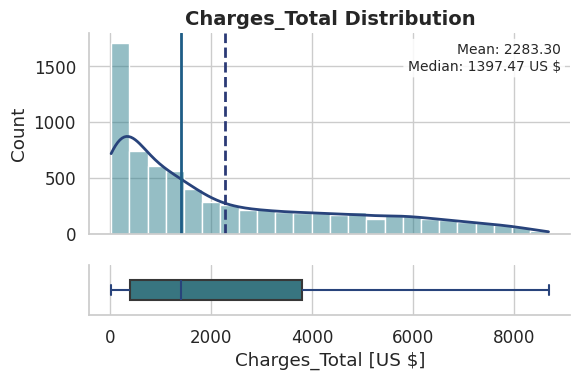

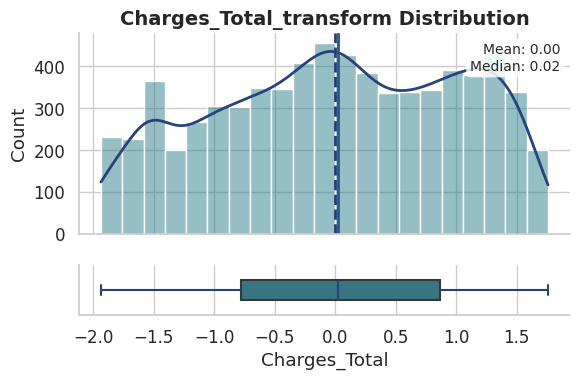

In [16]:
from sklearn.preprocessing import PowerTransformer

powerTransformer = PowerTransformer(method='box-cox',standardize=True)
#Charges_Total_transform = powerTransformer.fit_transform(X_trans[['Charges_Total']])
df_numeric_features.loc[:,'Charges_Total'] =  inspect_preprocessor(powerTransformer, X_trans[['Charges_Total']])

def plot_distributions_comparison(df,transformer,feature):
  #distibution before change
  distribution_plot(df[[feature]], feature, f'{feature} Distribution', x_unit=features_units[feature]).show()

  #after transform
  df_Charges_Total_frec=  inspect_preprocessor(transformer, df[[feature]])
  distribution_plot(df_Charges_Total_frec, feature, f'{feature}_transform Distribution').show()

plot_distributions_comparison(X_trans,powerTransformer,'Charges_Total')


/tmp/ipykernel_49358/4106980092.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.66428721 -0.66428721 -0.98561042 ... -1.25850769  1.14007693
  0.93779777]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_numeric_features.loc[:,'tenure'] =  inspect_preprocessor(quantile_transformer, X_trans[['tenure']])


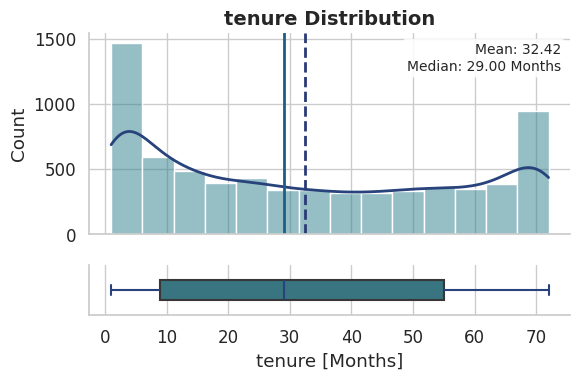

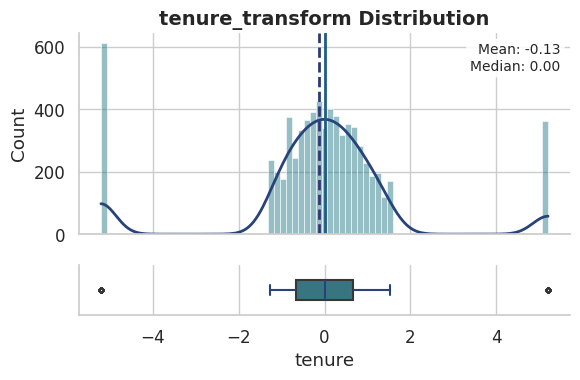

In [17]:
from sklearn.preprocessing import QuantileTransformer

quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=my_random_seed)
#tenure_quantile_transform = quantile_transformer.fit_transform(X_trans[['tenure']])
df_numeric_features.loc[:,'tenure'] =  inspect_preprocessor(quantile_transformer, X_trans[['tenure']])

plot_distributions_comparison(X_trans,quantile_transformer,'tenure')

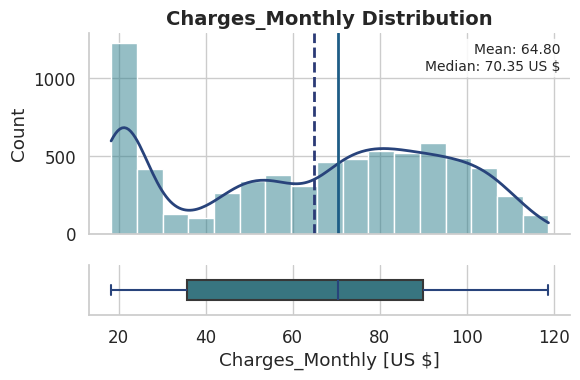

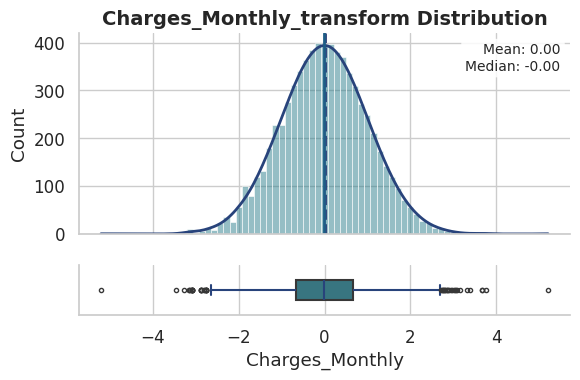

In [18]:
Charges_Monthly_quantile_transform = quantile_transformer.fit_transform(X_trans[['Charges_Monthly']])
df_numeric_features.loc[:,'Charges_Monthly'] =  inspect_preprocessor(quantile_transformer, X_trans[['Charges_Monthly']])
plot_distributions_comparison(X_trans,quantile_transformer, 'Charges_Monthly')

In [20]:
df_numeric_features.tail()

,tenure,Charges_Monthly,Charges_Total
7027,-0.475214,-0.318321,-0.416397
7028,-0.194422,0.494971,0.247299
7029,-1.258508,-0.436240,-1.443847
7030,1.140077,-0.095154,1.066066
7031,0.937798,-0.251581,0.847553


# Feature Selection

To improve model performance and interpretability, irrelevant or weakly informative variables will be removed.

This step includes:

- Correlation analysis with the target variable (Churn)

- Removing features with low predictive value

- Detecting multicollinearity between predictors

- Retaining variables that contribute meaningful information

**Feature selection helps reduce noise and prevent overfitting.**

In [43]:
# Correlation with the target, weak predictors |corr| < 0.05

df_numeric_features.loc[:,'Churn'] = y
corr_target = df_numeric_features.corr()["Churn"].sort_values(ascending=False)
display(corr_target[abs(corr_target)<0.05])

,Churn


In [44]:
df_categorical_onehot.loc[:,'Churn'] = y
corr_target = df_categorical_onehot.corr()["Churn"].sort_values(ascending=False)
display(corr_target[abs(corr_target)<0.05])

,Churn


In [45]:
df_binary_features.loc[:,'Churn'] = y
corr_target = df_binary_features.corr()["Churn"].sort_values(ascending=False)
display(corr_target[abs(corr_target)<0.05])

,Churn
MultipleLines,0.040033
PhoneService,0.011691
gender,-0.008545


In [49]:
new_binary_features = [ feature for feature in binary_features if feature not in corr_target[abs(corr_target)<0.05].index  ]


['SeniorCitizen',
 'Partner',
 'Dependents',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling']

In [ ]:
#Detecting multicollinearity

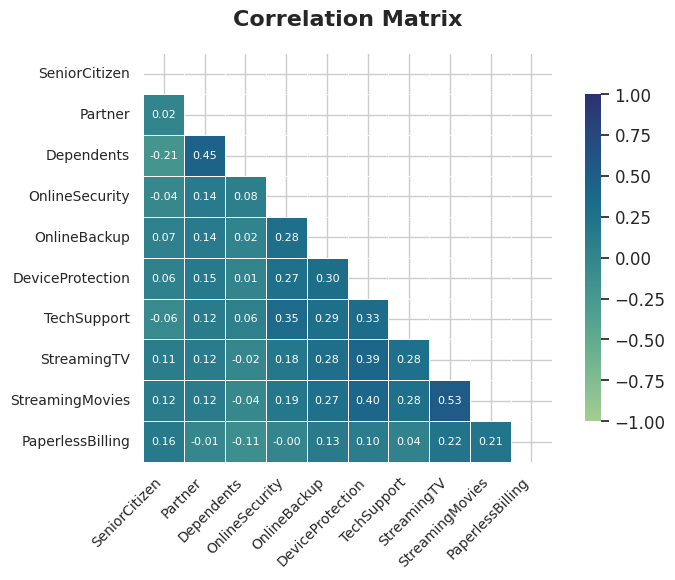

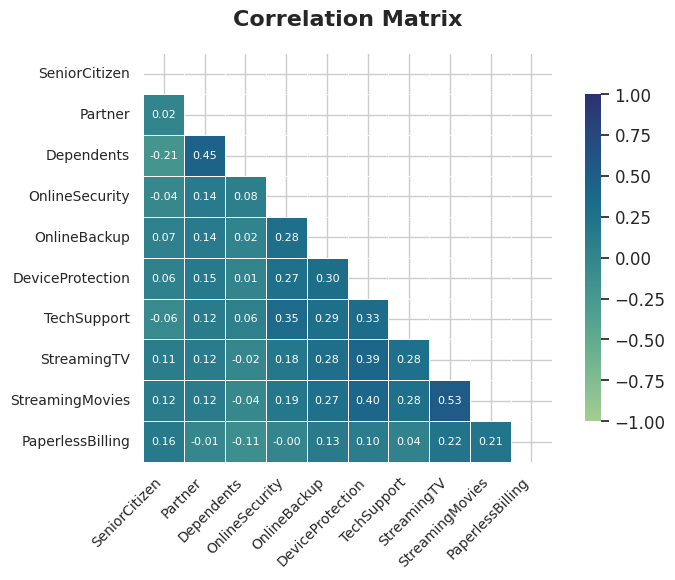

In [50]:
corr_plot(X_trans[new_binary_features])

In [73]:
import pandas as pd

# Para unirlos uno debajo del otro (Verticalmente)
#df_final = pd.concat([df_Charges_Monthly_frec, df_tenure_frec, df_Charges_Total_frec])

# Para unirlos de lado (Horizontalmente, alineando por índice)
df_final_side = pd.concat([df_Charges_Monthly_frec, df_tenure_frec, df_Charges_Total_frec], axis=1)
df_final_side.corr()

,Charges_Monthly,tenure,Charges_Total
Charges_Monthly,1.000000,0.268324,0.627435
tenure,0.268324,1.000000,0.762517
Charges_Total,0.627435,0.762517,1.000000


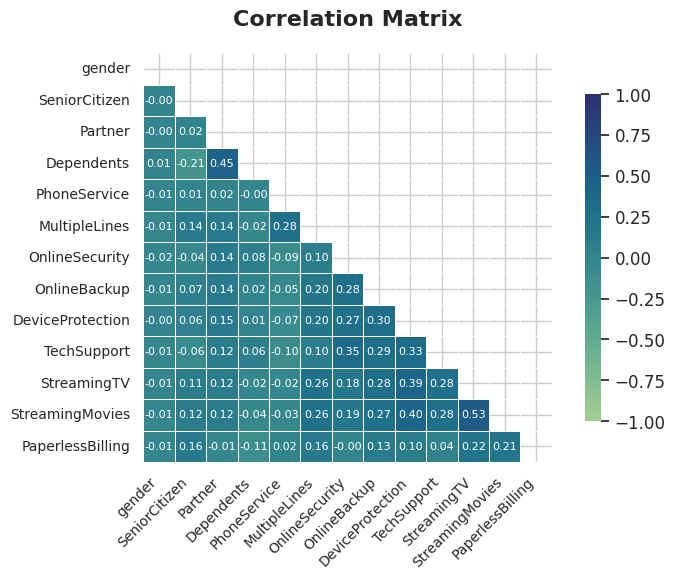

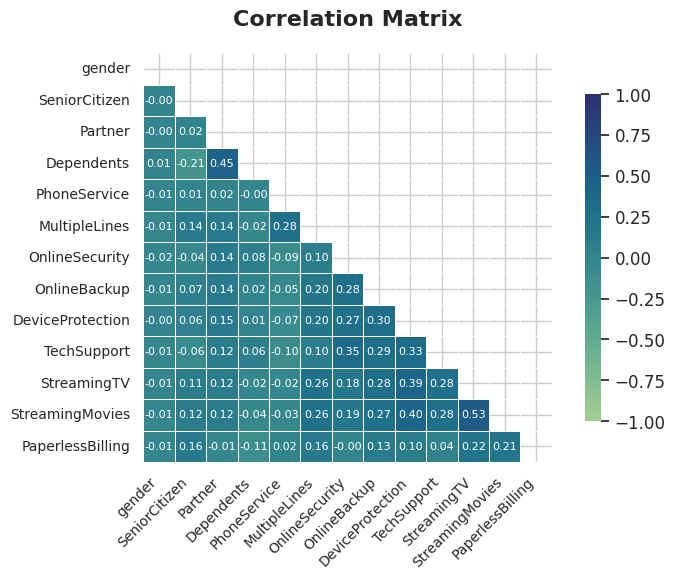

In [49]:
#X_trans[numeric_features].corr()



In [44]:
# ================================
# 6. Column Transformer
# ================================

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), categorical_onehot),
        ("num", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features)
    ]
)

In [45]:
# ================================
# 7. Full Pipeline
# ================================

pipeline = Pipeline(
    steps=[
        ("binary_mapper", BinaryMapper()),
        ("preprocessor", preprocessor)
    ]
)

In [46]:
# ================================
# 8. Train / Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 9. Fit Pipeline
# ================================

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (5625, 26)
Test shape: (1407, 26)


In [47]:
def get_processed_dataframe(pipeline, X):

    # apply the pipeline
    X_transformed = pipeline.transform(X)

    # get column names from the preprocessor
    preprocessor = pipeline.named_steps["preprocessor"]

    feature_names = preprocessor.get_feature_names_out()

    # create dataframe
    df_processed = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X.index
    )

    return df_processed

# Fit pipeline
pipeline.fit(X_train)

# Get transformed dataframe
df_train_processed = get_processed_dataframe(pipeline, X_train)

display(df_train_processed.head())

,onehot__InternetService_DSL,onehot__InternetService_Fiber optic,onehot__InternetService_No,onehot__Contract_Month-to-month,onehot__Contract_One year,onehot__Contract_Two year,onehot__PaymentMethod_Bank transfer (automatic),onehot__PaymentMethod_Credit card (automatic),onehot__PaymentMethod_Electronic check,onehot__PaymentMethod_Mailed check,...,binary__Dependents,binary__PhoneService,binary__MultipleLines,binary__OnlineSecurity,binary__OnlineBackup,binary__DeviceProtection,binary__TechSupport,binary__StreamingTV,binary__StreamingMovies,binary__PaperlessBilling
1457,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7226,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
3523,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4702,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
3715,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


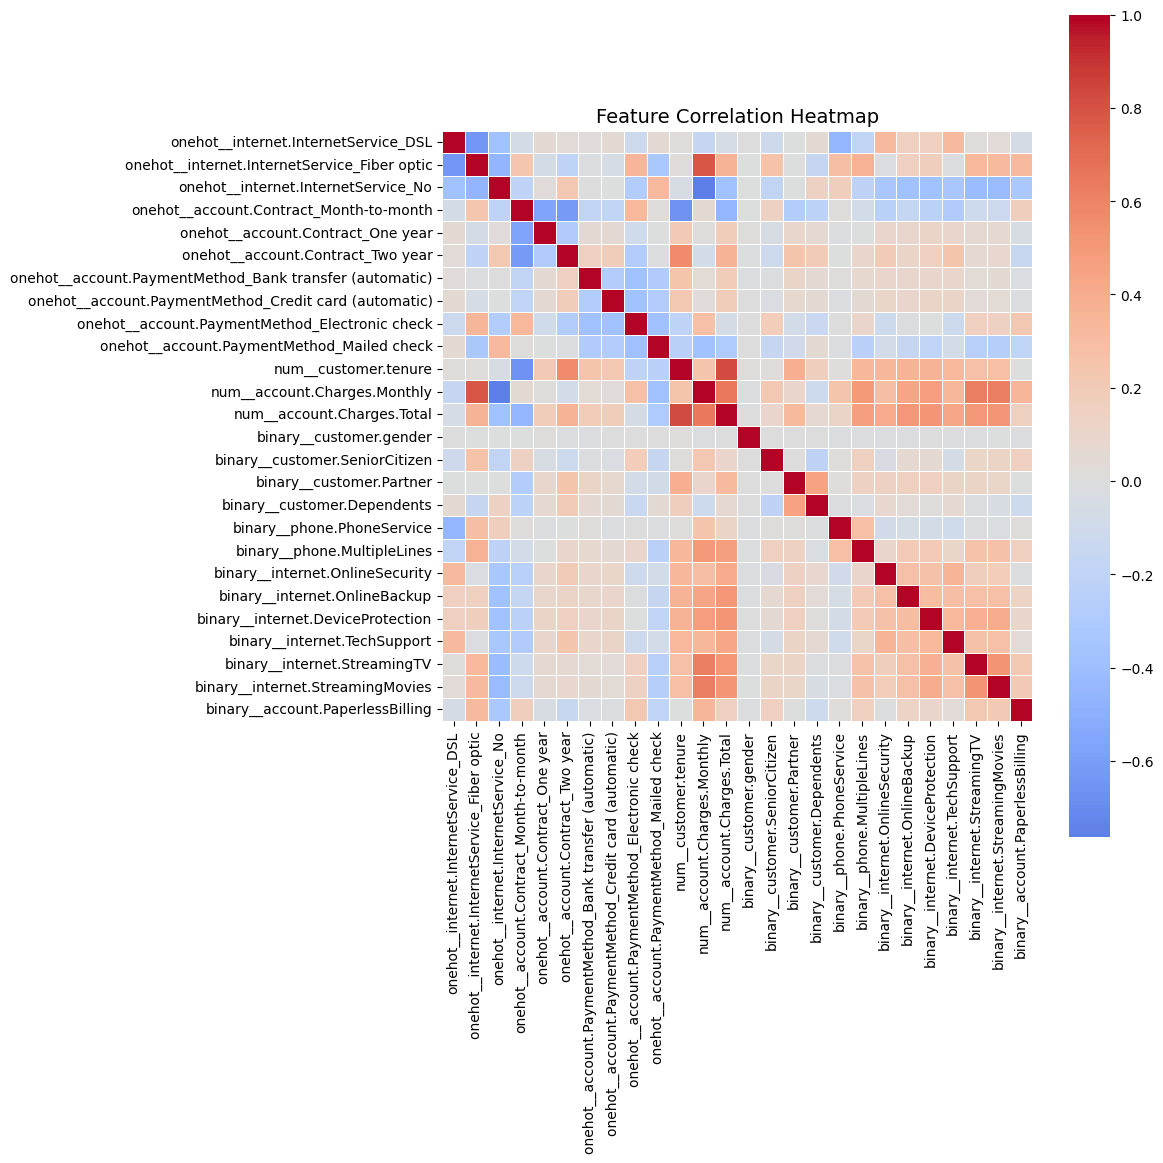

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(df, target=None, top_n=None, figsize=(12,12)):
    """
    Plot a correlation heatmap of a dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing numeric features.

    target : str, optional
        Target column to sort correlations by.

    top_n : int, optional
        Number of top correlated features with the target to visualize.

    figsize : tuple
        Size of the plot.
    """

    corr = df.corr()

    # If a target is specified, sort features by correlation
    if target is not None:

        corr_target = corr[target].abs().sort_values(ascending=False)

        if top_n is not None:
            selected_features = corr_target.head(top_n).index
            corr = corr.loc[selected_features, selected_features]

    plt.figure(figsize=figsize)

    sns.heatmap(
        corr,
        #annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5
    )

    plt.title("Feature Correlation Heatmap", fontsize=14)
    plt.tight_layout()
    plt.show()
plot_correlation_heatmap(df_train_processed)

In [ ]:
# ================================
# 10. saving data
# ================================
import joblib


df_train_processed.to_csv("df_train_processed.csv", index=False)

df_test_processed = get_processed_dataframe(pipeline, X_test)
df_test_processed.to_csv("df_test_processed.csv", index=False)

joblib.dump(pipeline, "preprocessing_pipeline.joblib")


In [ ]:
#pipeline = joblib.load("preprocessing_pipeline.joblib")
#X_new_processed = pipeline.transform(X_new)